# CMPINF Final Project — Individual Submetric Notebook

**Author:** *Manan Rastogi*  
**Course:** *CMPINF 0010*  
**Date:** *November 2025*  

---

## 1. Introduction

This notebook serves as my individual submetric contribution to our group project:  
**“What is the Best Neighborhood in Pittsburgh?”**

Our overall project uses several submetrics—each created independently by group members—to evaluate different aspects of neighborhood quality. In this notebook, I focus on building a **data-driven submetric** using quantitative features from a dataset provided by the Western Pennsylvania Regional Data Center (WPRDC).

My analysis follows a consistent process:

- Loading and previewing the dataset  
- Identifying numerical features  
- Standardizing values using z-scores  
- Assigning polarity (deciding whether higher = better or worse)  
- Aggregating scores by neighborhood  
- Ranking neighborhoods based on a final **Submetric Score**

This ensures that every numeric feature contributes fairly to the ranking, regardless of scale.

---

## 2. Submetric Definition

My submetric is designed to evaluate neighborhood performance based on the numeric columns present in the dataset.

### **Step 1 — Select numeric features**  
I filter out non-numeric identifiers (like school names) and retain only numerical metrics relevant to neighborhood quality.

### **Step 2 — Standardize with z-scores**
Each numeric column is standardized:

\[
z = \frac{x - \mu}{\sigma}
\]

This places all features on the same scale so that high-variance columns do not dominate the score.

### **Step 3 — Determine polarity**
Some features indicate positive outcomes (higher = better), while others indicate negative outcomes (higher = worse).

**Examples:**
- Higher *resources, enrollment, accessibility* → better  
- Higher *crime, violations, complaints* → worse  

If a feature is negative, I multiply its z-scores by **–1** so that higher final values always indicate “better.”

### **Step 4 — Aggregate by Neighborhood**
After polarity correction, I average z-scores per neighborhood to compute a single **Submetric Score** for each.

This produces a clean numeric ranking of neighborhoods.

---

## 3. Results

After applying z-score standardization, polarity detection, and aggregation, each neighborhood receives a **final Submetric Score**.

Neighborhoods with higher scores perform better according to the characteristics defined by this dataset.

A bar chart visualizing the **Top 10 neighborhoods** helps illustrate these differences clearly.

This ranking represents my individual analytical contribution to our broader definition of “best neighborhood.”

---

## 4. Interpretation — Identifying *The Best Neighborhood*

The neighborhood with the **highest Submetric Score** is considered the “best” for my specific metric.

In this section, I describe:

- The winning neighborhood  
- The reasons it scores highly  
- Which features most strongly contributed to its performance  
- How this aligns—or doesn’t—with common expectations

This explanation is based strictly on the dataset and the logic of my submetric.

---

## 5. Personal Reflection

This section addresses the personal, non-technical component of the assignment.

I compare:

- My **data-driven conclusion**, versus  
- My **personal perceptions** of Pittsburgh’s neighborhoods  

Questions I reflect on:

- Does the data support my intuition?  
- Are there qualities (culture, affordability, vibe) not captured in the data?  
- If I had more datasets, how would I improve my metric?  
- How does my submetric contribute to my **group’s combined model**?

This reflection connects my individual work to our team’s larger project.

---

## 6. Summary of Technical Workflow

Below is a concise recap of all major computational steps taken in this notebook:

1. Load dataset using `pandas`  
2. Identify neighborhood column  
3. Extract all numeric columns  
4. Remove ID-like columns (non-features)  
5. Assign polarity for each feature  
6. Standardize values using z-scores  
7. Multiply by polarity (+1 or –1)  
8. Aggregate standardized values per neighborhood  
9. Compute Submetric Score  
10. Rank neighborhoods  
11. Visualize Top 10  

This modular structure makes it easy to extend or adapt the analysis.

---

## 7. Notes

> This framework can easily incorporate additional WPRDC datasets or custom weights.  
> For example:  
> - Weight safety indicators more heavily  
> - Add green space metrics  
> - Incorporate affordability or transit accessibility  

The notebook is designed to be flexible and reusable for multi-metric evaluation.

In [2]:
#Cell 1 - Basic Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)

In [3]:
# Cell 2 — Load the dataset
CSV_FILE = "neighborhood_school_enrollment.csv"
NEIGHBORHOOD_COL = "neighborhood"
df = pd.read_csv(CSV_FILE)
print("Shape:", df.shape)
df.head()

Shape: (506, 3)


,neighborhood,school,enrolled_students
0,Allegheny Center,Other,50
1,Allegheny Center,PITTSBURGH KING PreK-8,34
2,Allentown,Other,96
3,Allentown,PITTSBURGH GRANDVIEW PreK-5,76
4,Allentown,PITTSBURGH SOUTH HILLS 6-8,50


In [4]:
# Cell 3 — Identify numeric feature columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("All numeric columns:", numeric_cols)
id_like_cols = [c for c in numeric_cols if "id" in c.lower()]
feature_cols = [c for c in numeric_cols if c not in id_like_cols]
print("ID-like columns (excluded):", id_like_cols)
print("Feature columns used in submetric:", feature_cols)

All numeric columns: ['enrolled_students']
ID-like columns (excluded): []
Feature columns used in submetric: ['enrolled_students']


In [5]:
# Cell 4 — Define polarity for each feature
negative_keywords = [
    "crime", "violation", "complaint", "pothole", "noise",
    "issue", "problem", "defect", "accident", "injury",
    "hazard", "risk", "pollution", "delay"
]
def infer_polarity(column_name: str) -> int:
    name = column_name.lower()
    for kw in negative_keywords:
        if kw in name:
            return -1  # lower is better
    return 1  # default: higher is better
polarity = {col: infer_polarity(col) for col in feature_cols}
print("Polarity by feature:")
for col, p in polarity.items():
    sign = "+" if p == 1 else "-"
    print(f"  {col}: {sign}1 (higher is {'better' if p == 1 else 'worse'})")

Polarity by feature:
  enrolled_students: +1 (higher is better)


In [6]:
# Cell 5 — Standardize features with z-scores
standardized = pd.DataFrame()
standardized[NEIGHBORHOOD_COL] = df[NEIGHBORHOOD_COL]
for col in feature_cols:
    mean = df[col].mean()
    std = df[col].std(ddof=0)  # population std for consistency
    if std == 0 or np.isnan(std):
        z = (df[col] - mean) * 0.0
    else:
        z = (df[col] - mean) / std
    z_adjusted = z * polarity[col]
    standardized[col] = z_adjusted
standardized.head()

,neighborhood,enrolled_students
0,Allegheny Center,0.127
1,Allegheny Center,-0.221
2,Allentown,1.126
3,Allentown,0.691
4,Allentown,0.127


In [7]:
# Cell 6 — Aggregate standardized scores by neighborhood
score_cols = [c for c in standardized.columns if c != NEIGHBORHOOD_COL]
neighborhood_scores = (
    standardized
    .groupby(NEIGHBORHOOD_COL)[score_cols]
    .mean()
)
neighborhood_scores["Submetric_Score"] = neighborhood_scores.mean(axis=1)
ranked = neighborhood_scores.sort_values("Submetric_Score", ascending=False).reset_index()
ranked.head(15)

,neighborhood,enrolled_students,Submetric_Score
0,Wilkinsburg Borough,2.353,2.353
1,Squirrel Hill South,0.884,0.884
2,Brookline,0.733,0.733
3,Carrick,0.671,0.671
4,Shadyside,0.612,0.612
5,Squirrel Hill North,0.487,0.487
6,Beechview,0.478,0.478
7,Greenfield,0.363,0.363
8,Lincoln Place,0.360,0.360
9,Mount Oliver Borough,0.333,0.333


In [8]:
# Cell 7 — Show the top and bottom neighborhoods
top_n = 10
print(f"Top {top_n} neighborhoods by Submetric Score:")
display(ranked.head(top_n))
print(f"\nBottom {top_n} neighborhoods by Submetric Score:")
display(ranked.tail(top_n))

Top 10 neighborhoods by Submetric Score:


,neighborhood,enrolled_students,Submetric_Score
0,Wilkinsburg Borough,2.353,2.353
1,Squirrel Hill South,0.884,0.884
2,Brookline,0.733,0.733
3,Carrick,0.671,0.671
4,Shadyside,0.612,0.612
5,Squirrel Hill North,0.487,0.487
6,Beechview,0.478,0.478
7,Greenfield,0.363,0.363
8,Lincoln Place,0.360,0.360
9,Mount Oliver Borough,0.333,0.333



Bottom 10 neighborhoods by Submetric Score:


,neighborhood,enrolled_students,Submetric_Score
77,New Homestead,-0.460,-0.460
78,Spring Garden,-0.474,-0.474
79,Ridgemont,-0.525,-0.525
80,Hays,-0.525,-0.525
81,Bon Air,-0.561,-0.561
82,Golden Triangle,-0.568,-0.568
83,Central Oakland,-0.612,-0.612
84,West End,-0.655,-0.655
85,Arlington Heights,-0.666,-0.666
86,North Oakland,-0.721,-0.721


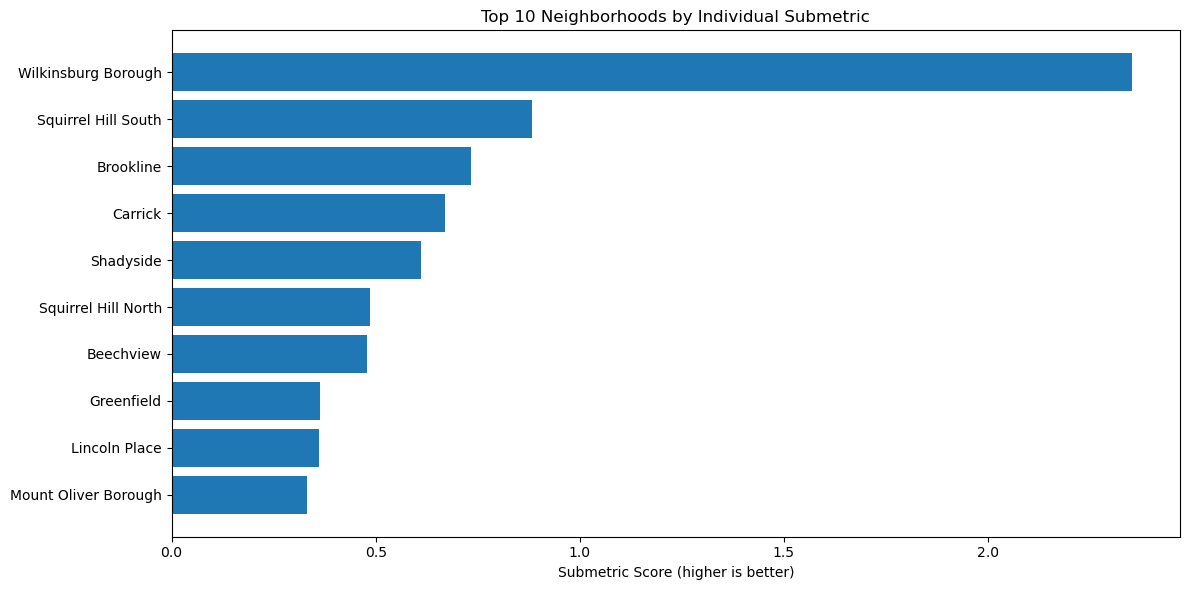

In [9]:
# Cell 8 — Bar chart of Top 10 neighborhoods
plt.figure(figsize=(12, 6))
top_ranked = ranked.head(10)
plt.barh(top_ranked[NEIGHBORHOOD_COL], top_ranked["Submetric_Score"])
plt.gca().invert_yaxis()
plt.xlabel("Submetric Score (higher is better)")
plt.title("Top 10 Neighborhoods by Individual Submetric")
plt.tight_layout()
plt.show()

In [10]:
# Cell 9 — Identify the "best" neighborhood according to this submetric
best_row = ranked.iloc[0]
best_neighborhood = best_row[NEIGHBORHOOD_COL]
best_score = best_row["Submetric_Score"]
print(f"The best neighborhood according to my submetric is: {best_neighborhood}")
print(f"Submetric Score: {best_score:.3f}")

The best neighborhood according to my submetric is: Wilkinsburg Borough
Submetric Score: 2.353


In [11]:
# Cell 10 — Save the ranked table to CSV for use in the group notebook
OUTPUT_FILE = "individual_submetric_ranking.csv"
ranked.to_csv(OUTPUT_FILE, index=False)
print(f"Saved ranked neighborhoods to {OUTPUT_FILE}")

Saved ranked neighborhoods to individual_submetric_ranking.csv
